# Part 2 — Apps to Clone + Add Features

**Goal:** Find specific apps where demand is proven but users are unhappy.  
The market is there — the current apps just fail to deliver. Build a better version.

**Signals:**
- High installs (>100K) but low rating (<3.5) — demand proven, execution broken
- Apps that haven't been updated in 2+ years — stale product, ripe for disruption
- Categories where the #1 app has a bad rating — leader is weak, throne is open
- High reviews-to-rating ratio — lots of engagement but people are frustrated
- Specific complaint patterns (ads, crashes, paywalls, UI) — tell you what to fix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

TAPIVE_RELATIVE = 'data_my_copy/google-play-dataset-by-tapivedotcom.csv/google-play-dataset-by-tapivedotcom.csv'
APPS26_RELATIVE = 'data/scraped_2026/apps.csv'

def find_project_root():
    candidates = [Path().resolve()]
    p = Path().resolve()
    for _ in range(10):
        p = p.parent
        candidates.append(p)
    for c in candidates:
        if (c / TAPIVE_RELATIVE).exists():
            return c
    raise FileNotFoundError(f'Cannot find Tapive CSV. Searched: {candidates}')

ROOT = find_project_root()
TAPIVE_PATH = str(ROOT / TAPIVE_RELATIVE)
APPS_2026_PATH = str(ROOT / APPS26_RELATIVE)
print(f'Project root: {ROOT}')

print('Loading datasets...')
tap = pd.read_csv(TAPIVE_PATH, low_memory=False)
apps26 = pd.read_csv(APPS_2026_PATH, low_memory=False)
print(f'Tapive: {len(tap):,} | 2026: {len(apps26):,}')

Project root: D:\Projects\play-store-analysis-github
Loading datasets...


Tapive: 3,451,063 | 2026: 11,176


In [2]:
# Clean both datasets
tap['minInstalls'] = pd.to_numeric(tap['minInstalls'], errors='coerce')
tap['score'] = pd.to_numeric(tap['score'], errors='coerce')
tap['ratings'] = pd.to_numeric(tap['ratings'], errors='coerce')
tap['reviews'] = pd.to_numeric(tap['reviews'], errors='coerce')

tap_clean = tap.dropna(subset=['genre','score','minInstalls','title']).copy()
tap_clean = tap_clean[tap_clean['minInstalls'] > 0]
tap_clean = tap_clean[tap_clean['score'] > 0]

apps26['min_installs'] = pd.to_numeric(apps26['min_installs'], errors='coerce')
apps26['score'] = pd.to_numeric(apps26['score'], errors='coerce')
apps26['reviews'] = pd.to_numeric(apps26['reviews'], errors='coerce')
apps26['ratings'] = pd.to_numeric(apps26['ratings'], errors='coerce')

apps26_clean = apps26.dropna(subset=['genre','score','min_installs','title']).copy()
apps26_clean = apps26_clean[apps26_clean['min_installs'] > 0]
apps26_clean = apps26_clean[apps26_clean['score'] > 0]

print(f'Tap clean: {len(tap_clean):,} | 2026 clean: {len(apps26_clean):,}')

Tap clean: 445,538 | 2026 clean: 7,910


## Signal 1 — High Installs, Low Rating (Tapive 3.4M)
These apps PROVED demand but users hate them. Perfect clone targets.

In [3]:
# High installs + low score = clone candidate
clone_candidates = tap_clean[
    (tap_clean['minInstalls'] >= 100_000) &
    (tap_clean['score'] < 3.5) &
    (tap_clean['score'] > 1.0)  # exclude spam/fake
].copy()

clone_candidates['clone_score'] = (
    np.log10(clone_candidates['minInstalls'] + 1) * (4.0 - clone_candidates['score'])
)

clone_candidates_sorted = clone_candidates.sort_values('clone_score', ascending=False)

print(f'Clone candidates (>=100K installs, score < 3.5): {len(clone_candidates_sorted):,}')
print('\nTop 30 apps to clone + improve:')
print(clone_candidates_sorted[['title','genre','minInstalls','score','reviews']]
      .head(30).to_string(index=False))

Clone candidates (>=100K installs, score < 3.5): 28,921

Top 30 apps to clone + improve:
                         title             genre  minInstalls  score  reviews
           Android TV Launcher             Tools    100000000   1.08      144
               Android TV Home             Tools    100000000   1.08      600
      Android TV Core Services             Tools    100000000   1.28       47
        あんしんフィルター for SoftBank             Tools     10000000   1.17        4
                   MyPertamina          Business      5000000   1.12      402
                おサイフケータイ 設定アプリ             Tools     50000000   1.55        4
                      Testfoni            Social     10000000   1.35     1554
        YouTube for Android TV     Entertainment    100000000   1.72      143
                  정부24(구 민원24)      Productivity     10000000   1.43       17
                   Draw n Road            Puzzle     10000000   1.43      717
      Prime Video - Android TV     Entertainment    1

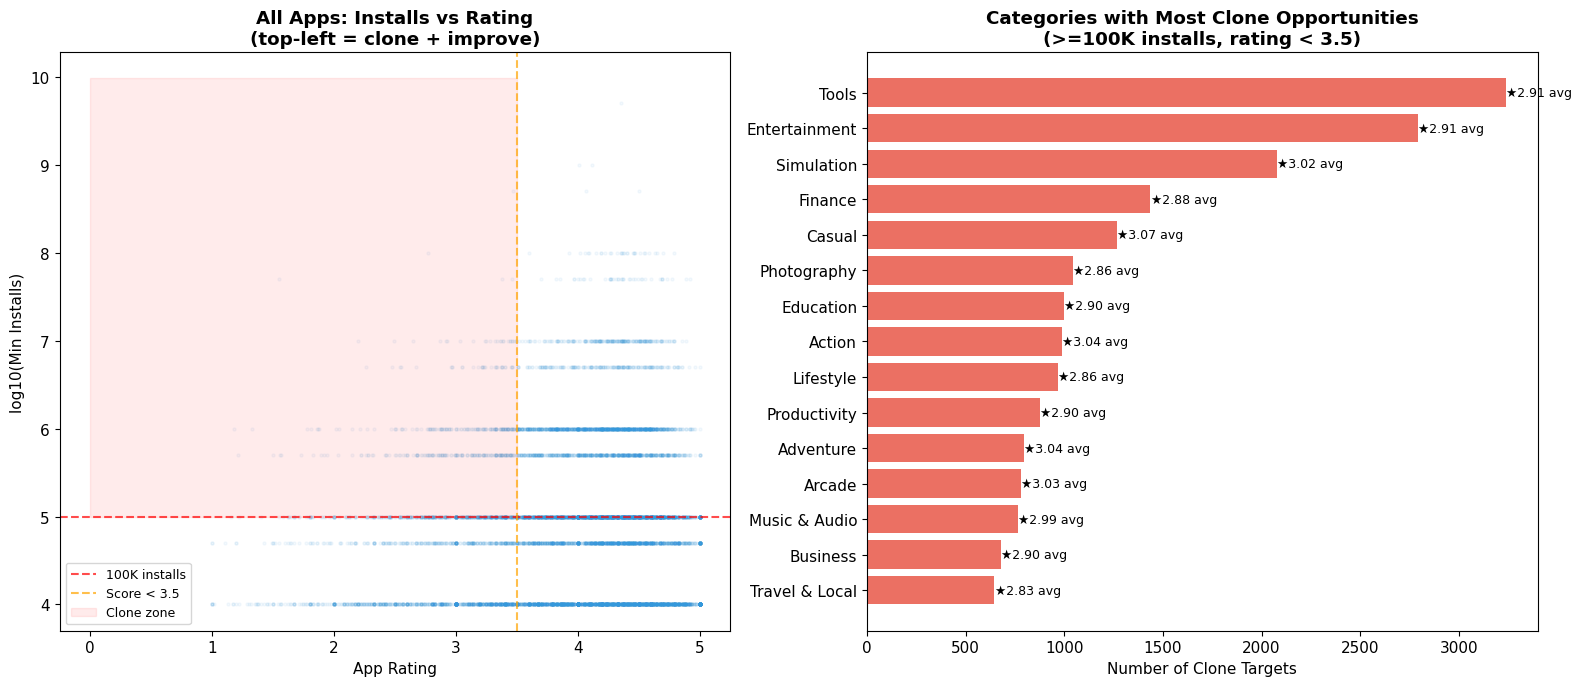

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: density scatter — installs vs score for all apps
ax = axes[0]
sample = tap_clean[tap_clean['minInstalls'] >= 10_000].sample(min(10000, len(tap_clean)), random_state=42)
ax.scatter(sample['score'], np.log10(sample['minInstalls']+1),
           alpha=0.05, s=5, color='#3498db')
# Highlight clone zone
ax.axhline(np.log10(100_000), color='red', linestyle='--', alpha=0.7, label='100K installs')
ax.axvline(3.5, color='orange', linestyle='--', alpha=0.7, label='Score < 3.5')
ax.fill_betweenx([np.log10(100_000), ax.get_ylim()[1] if ax.get_ylim()[1] > 5 else 9],
                  0, 3.5, alpha=0.08, color='red', label='Clone zone')
ax.set_xlabel('App Rating')
ax.set_ylabel('log10(Min Installs)')
ax.set_title('All Apps: Installs vs Rating\n(top-left = clone + improve)', fontweight='bold')
ax.legend(fontsize=9)

# Right: top genres in clone zone
ax2 = axes[1]
genre_clone = clone_candidates.groupby('genre').agg(
    count=('appId','count'),
    avg_installs=('minInstalls','mean'),
    avg_score=('score','mean')
).reset_index().sort_values('count', ascending=False).head(15)

genre_clone_s = genre_clone.sort_values('count')
bars = ax2.barh(genre_clone_s['genre'], genre_clone_s['count'], color='#e74c3c', alpha=0.8)
for bar, row in zip(bars, genre_clone_s.itertuples()):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'★{row.avg_score:.2f} avg', va='center', fontsize=9)
ax2.set_xlabel('Number of Clone Targets')
ax2.set_title('Categories with Most Clone Opportunities\n(>=100K installs, rating < 3.5)', fontweight='bold')

plt.tight_layout()
plt.savefig('p2_clone_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 2 — Stale Apps with High Installs (Abandoned Throne)
Apps that were great but stopped updating. Users are stuck with them.  
A maintained competitor wins by default.

In [5]:
# Parse update dates
tap_clean['dateUpdated'] = pd.to_datetime(tap_clean['dateUpdated'], errors='coerce')

# Use 2024 as reference (dataset was scraped ~2024)
ref_date = pd.Timestamp('2024-01-01')
tap_clean['months_since_update'] = ((ref_date - tap_clean['dateUpdated']).dt.days / 30).clip(0, 60)

stale = tap_clean[
    (tap_clean['minInstalls'] >= 500_000) &
    (tap_clean['months_since_update'] >= 24) &   # 2+ years no update
    (tap_clean['score'] >= 3.0)  # was decent, just abandoned
].copy()

stale['stale_score'] = np.log10(stale['minInstalls']+1) * stale['months_since_update']
stale_sorted = stale.sort_values('stale_score', ascending=False)

print(f'Stale apps with 500K+ installs, 2+ years no update: {len(stale_sorted):,}')
print('\nTop 25 abandoned apps worth cloning:')
print(stale_sorted[['title','genre','minInstalls','score','months_since_update']]
      .head(25).to_string(index=False))

Stale apps with 500K+ installs, 2+ years no update: 30,699

Top 25 abandoned apps worth cloning:
                         title                   genre  minInstalls  score  months_since_update
                 Secure Folder                Business   1000000000   3.83            60.000000
     Samsung Link (Terminated)            Productivity    500000000   3.47            60.000000
Layout from Instagram: Collage             Photography    100000000   4.45            60.000000
                  Write on PDF            Productivity    100000000   3.55            60.000000
               Timeshift burst             Photography    100000000   4.28            60.000000
             Moto Photo Editor             Photography    100000000   4.12            60.000000
                      TubeMote           Entertainment    100000000   3.47            60.000000
           Angry Birds Seasons                  Arcade    100000000   4.58            60.000000
               Account Manager         

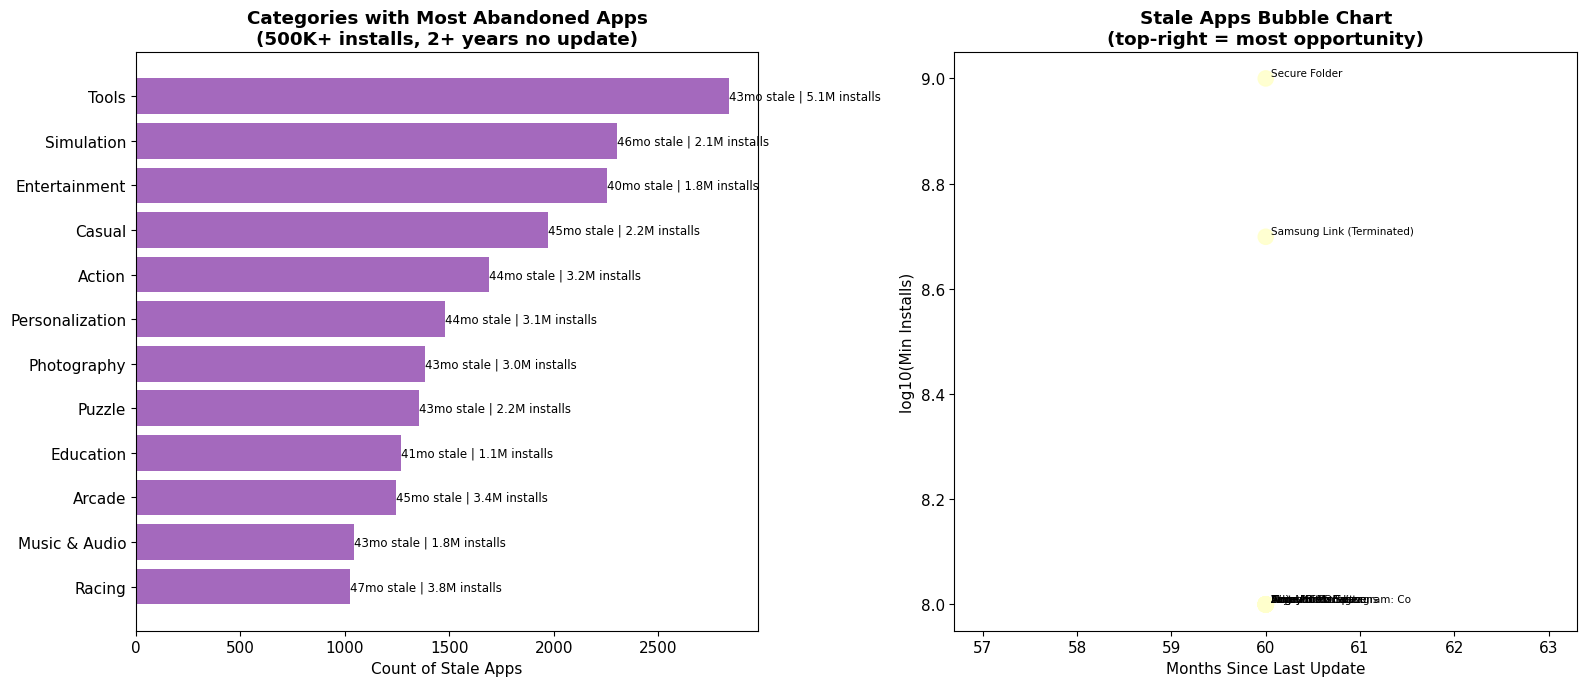

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
stale_genre = stale.groupby('genre').agg(
    count=('appId','count'),
    avg_installs=('minInstalls','mean'),
    avg_months=('months_since_update','mean')
).reset_index().sort_values('count', ascending=False).head(12)
sg = stale_genre.sort_values('count')
bars = ax1.barh(sg['genre'], sg['count'], color='#8e44ad', alpha=0.8)
for bar, row in zip(bars, sg.itertuples()):
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{row.avg_months:.0f}mo stale | {row.avg_installs/1e6:.1f}M installs',
             va='center', fontsize=8.5)
ax1.set_xlabel('Count of Stale Apps')
ax1.set_title('Categories with Most Abandoned Apps\n(500K+ installs, 2+ years no update)', fontweight='bold')

ax2 = axes[1]
top_stale = stale_sorted.head(15)
colors = plt.cm.YlOrRd(top_stale['months_since_update'] / top_stale['months_since_update'].max())
ax2.scatter(top_stale['months_since_update'], np.log10(top_stale['minInstalls']+1),
            c=top_stale['months_since_update'], cmap='YlOrRd', s=120, alpha=0.9)
for _, row in top_stale.head(10).iterrows():
    ax2.annotate(row['title'][:25], (row['months_since_update'], np.log10(row['minInstalls']+1)),
                 fontsize=7.5, xytext=(4, 2), textcoords='offset points')
ax2.set_xlabel('Months Since Last Update')
ax2.set_ylabel('log10(Min Installs)')
ax2.set_title('Stale Apps Bubble Chart\n(top-right = most opportunity)', fontweight='bold')

plt.tight_layout()
plt.savefig('p2_stale_apps.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 3 — Weak Category Leaders (2026 Data)
In some categories, the #1 app has a rating below 4.0.  
If the best app in the category is mediocre, you only need to be "good" to dominate.

In [7]:
# Per category: find the top app (by installs), check its rating
cat_leader = apps26_clean.sort_values('min_installs', ascending=False)
cat_leader = cat_leader.groupby('genre').first().reset_index()
cat_leader = cat_leader[cat_leader['min_installs'] >= 10_000]

weak_leaders = cat_leader[cat_leader['score'] < 4.0].sort_values('min_installs', ascending=False)

print(f'Categories where the #1 app (by installs) has rating < 4.0: {len(weak_leaders)}')
print('\nTop weak leaders (easiest to dethrone):')
print(weak_leaders[['genre','title','min_installs','score','reviews']]
      .head(20).to_string(index=False))

Categories where the #1 app (by installs) has rating < 4.0: 10

Top weak leaders (easiest to dethrone):
                  genre                          title  min_installs    score  reviews
Video Players & Editors                      Google TV  1.000000e+10 3.934762  76253.0
         Travel & Local                    Google Maps  1.000000e+10 3.221151 677633.0
          Entertainment              Google Play Games  5.000000e+09 3.969200 201465.0
       Health & Fitness                 Samsung Health  1.000000e+09 3.393806  77528.0
       News & Magazines                              X  1.000000e+09 3.623819 785781.0
                 Dating Tinder Dating App: Chat & Date  5.000000e+08 3.787734 276126.0
             Simulation   My Supermarket Simulator 3D®  1.000000e+08 3.666056   5119.0
           Food & Drink  Rappi: Food Delivery, Grocery  1.000000e+08 3.420259   8635.0
                 Beauty Perfect365 Makeup Photo Editor  5.000000e+07 3.530444  48345.0
                Medical   

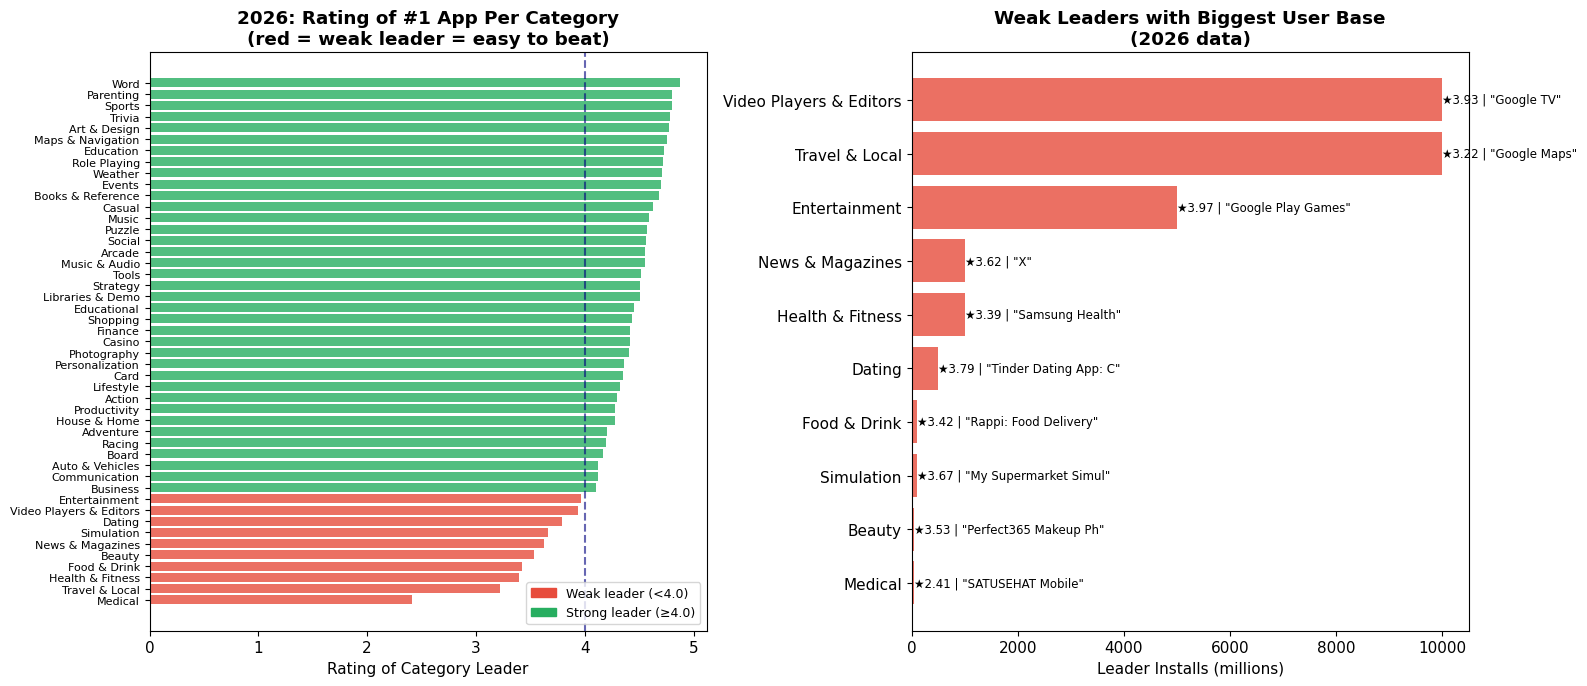

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
all_leaders = cat_leader.sort_values('score', ascending=True)
colors = ['#e74c3c' if s < 4.0 else '#27ae60' for s in all_leaders['score']]
ax1.barh(range(len(all_leaders)), all_leaders['score'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(all_leaders)))
ax1.set_yticklabels([f"{g[:25]}" for g in all_leaders['genre']], fontsize=8)
ax1.axvline(4.0, color='navy', linestyle='--', alpha=0.6, label='4.0 threshold')
ax1.set_xlabel('Rating of Category Leader')
ax1.set_title('2026: Rating of #1 App Per Category\n(red = weak leader = easy to beat)', fontweight='bold')
red_patch = mpatches.Patch(color='#e74c3c', label='Weak leader (<4.0)')
green_patch = mpatches.Patch(color='#27ae60', label='Strong leader (≥4.0)')
ax1.legend(handles=[red_patch, green_patch], fontsize=9)

ax2 = axes[1]
top_wl = weak_leaders.head(12).sort_values('min_installs')
bars = ax2.barh(top_wl['genre'], top_wl['min_installs']/1e6, color='#e74c3c', alpha=0.8)
for bar, row in zip(bars, top_wl.itertuples()):
    ax2.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
             f'★{row.score:.2f} | "{row.title[:20]}"',
             va='center', fontsize=8.5)
ax2.set_xlabel('Leader Installs (millions)')
ax2.set_title('Weak Leaders with Biggest User Base\n(2026 data)', fontweight='bold')

plt.tight_layout()
plt.savefig('p2_weak_leaders.png', dpi=150, bbox_inches='tight')
plt.show()

## Final: Top Specific Apps to Clone + Improve
Combining all signals: high installs, bad rating, stale, or weak leader.

In [9]:
# Best clone+improve targets from Tapive (large dataset)
final_clones = clone_candidates_sorted[['title','genre','minInstalls','score','reviews']].head(40).copy()
final_clones['why'] = 'High installs + poor rating'

# Add stale high-value apps
stale_top = stale_sorted[['title','genre','minInstalls','score']].head(20).copy()
stale_top['reviews'] = np.nan
stale_top['why'] = 'Abandoned (2+ years no update)'

combined = pd.concat([final_clones, stale_top], ignore_index=True)
combined = combined.drop_duplicates(subset='title')

print('='*80)
print('PART 2 FINAL: Apps to Clone + Improve')
print('='*80)
for i, row in combined.head(30).iterrows():
    print(f"{i+1:2}. [{row['genre']:<25}] {row['title']:<35} | "
          f"★{row['score']:.1f} | {row['minInstalls']/1e6:.1f}M installs | {row['why']}")

PART 2 FINAL: Apps to Clone + Improve
 1. [Tools                    ] Android TV Launcher                 | ★1.1 | 100.0M installs | High installs + poor rating
 2. [Tools                    ] Android TV Home                     | ★1.1 | 100.0M installs | High installs + poor rating
 3. [Tools                    ] Android TV Core Services            | ★1.3 | 100.0M installs | High installs + poor rating
 4. [Tools                    ] あんしんフィルター for SoftBank              | ★1.2 | 10.0M installs | High installs + poor rating
 5. [Business                 ] MyPertamina                         | ★1.1 | 5.0M installs | High installs + poor rating
 6. [Tools                    ] おサイフケータイ 設定アプリ                      | ★1.6 | 50.0M installs | High installs + poor rating
 7. [Social                   ] Testfoni                            | ★1.4 | 10.0M installs | High installs + poor rating
 8. [Entertainment            ] YouTube for Android TV              | ★1.7 | 100.0M installs | High instal

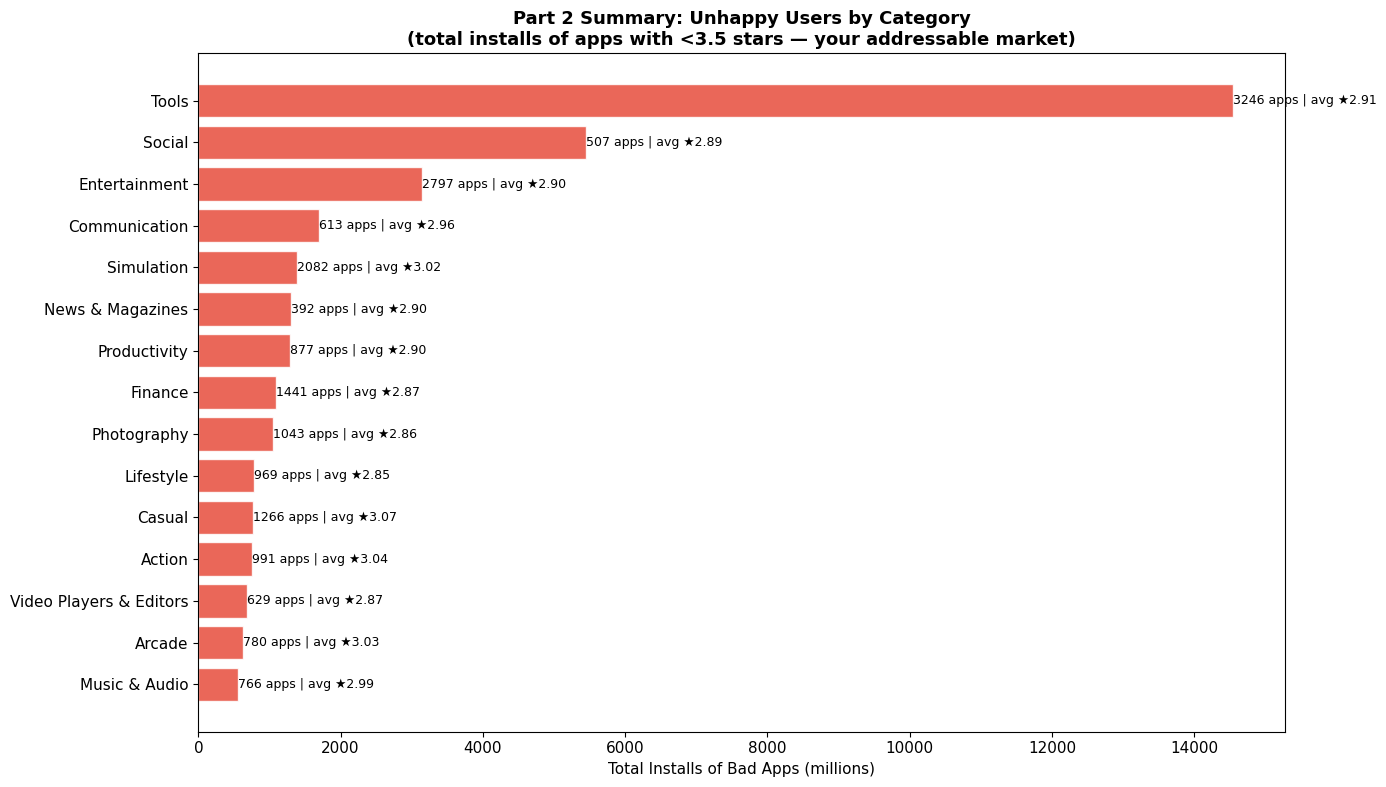

All Part 2 charts saved.


In [10]:
# What features to add — based on install/rating gap analysis per category
improvement_map = tap_clean[
    (tap_clean['minInstalls'] >= 100_000) & 
    (tap_clean['score'] < 3.5)
].groupby('genre').agg(
    apps_to_improve=('appId','count'),
    avg_bad_score=('score','mean'),
    total_unhappy_installs=('minInstalls','sum')
).reset_index().sort_values('total_unhappy_installs', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_im = improvement_map.head(15).sort_values('total_unhappy_installs')
bars = ax.barh(top_im['genre'], top_im['total_unhappy_installs']/1e6, 
               color='#e74c3c', alpha=0.85, edgecolor='white')
for bar, row in zip(bars, top_im.itertuples()):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{row.apps_to_improve} apps | avg ★{row.avg_bad_score:.2f}',
             va='center', fontsize=9)
ax.set_xlabel('Total Installs of Bad Apps (millions)')
ax.set_title('Part 2 Summary: Unhappy Users by Category\n'
             '(total installs of apps with <3.5 stars — your addressable market)', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('p2_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('All Part 2 charts saved.')